In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pickle
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

In [3]:
stepwise_results = list(Path("outputs/trf_stepwise").glob("*/results.pkl"))
outdir = "."
all_electrode_dfs = list(Path("outputs/causal4/find_speech_responsive").glob("*_results.csv"))

In [4]:
stepwise_results = [Path(p) for p in stepwise_results]
outdir = Path(outdir)

In [5]:
electrode_df = pd.concat([pd.read_csv(path) for path in all_electrode_dfs]).set_index(["subject", "electrode_idx"])

In [6]:
all_results = []
for path in tqdm(stepwise_results):
    subject = path.parent.name
    with path.open("rb") as f:
        st = pickle.load(f)

    for progression in st:
        if st[progression]["ftest_results"] is None:
            # no matching electrodes here, so we skipped the analysis. all good
            continue

        for ftest_results in st[progression]["ftest_results"]:
            # get the more advanced model in this comparison ("step2")
            cv_results = st[progression]["cv_results"][ftest_results["step2"]]
            fit_electrodes = cv_results["cv_results"]["estimator"][0].estimator.fit_electrodes

            for i, elec in enumerate(fit_electrodes):
                all_results.append({
                    "subject": subject,
                    "progression": progression,
                    "progression_step": cv_results["progression_step"],
                    "electrode": elec,
                    "r2_pre": st[progression]["cv_results"][ftest_results["step1"]]["r2"][i],
                    "r2_post": cv_results["r2"][i],
                    "rss_pre": ftest_results["rss_1"][i],
                    "rss_post": ftest_results["rss_2"][i],
                    "df_diff": ftest_results["df_diff"],
                    "df_residual": ftest_results["df_residual"],
                    "ftest_stat": ftest_results["f_stat"][i],
                    "ftest_pval": ftest_results["p_value"][i],
                })

  0%|          | 0/10 [00:00<?, ?it/s]

/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.3.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.3.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.3.0 wh

In [7]:
all_results_df = pd.DataFrame(all_results)
all_results_df["rss_diff"] = all_results_df["rss_post"] - all_results_df["rss_pre"]

# merge electrode information
all_results_df = pd.merge(all_results_df, electrode_df, left_on=["subject", "electrode"], right_on=["subject", "electrode_idx"])

r2_valid_df = all_results_df.loc[all_results_df.r2_pre > 0]
all_results_df.loc[all_results_df.r2_pre > 0, "r2_diff"] = r2_valid_df["r2_post"] - r2_valid_df["r2_pre"]
all_results_df.sort_values("ftest_pval")

,subject,progression,progression_step,electrode,r2_pre,r2_post,rss_pre,rss_post,df_diff,df_residual,ftest_stat,ftest_pval,rss_diff,long_name,type,roi,speech_responsive,r2_diff
27,EC250,acoustic,1,215,0.046851,0.064466,1.003270,0.984729,243,102708,7.958092,9.940204e-258,-0.018541,Inferior88,grid,superiortemporal,True,0.017615
77,EC253,acoustic,1,21,0.031876,0.041310,1.529987,1.515077,243,102708,4.159245,1.536533e-93,-0.014909,AnteriorGrid22,grid,postcentral,True,0.009434
104,EC287,acoustic,1,124,-0.022502,-0.013947,1.035748,1.027083,243,68148,2.366036,9.076254e-29,-0.008665,TemporalGrid125,grid,superiortemporal,False,NaN
28,EC250,acoustic,1,216,0.015503,0.020762,1.205816,1.199374,243,102708,2.270015,6.230679e-26,-0.006441,Inferior89,grid,superiortemporal,True,0.005259
43,EC282,acoustic,1,84,-0.002842,0.007772,1.500747,1.484864,243,50868,2.239263,6.329682e-25,-0.015884,Temporal85,grid,superiortemporal,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,EC243,mismatch,1,228,-0.000701,-0.001236,0.852132,0.852587,243,102708,-0.225651,1.000000e+00,0.000455,SuperiorParietal101,grid,caudalmiddlefrontal,False,NaN
225,EC279,mismatch,2,167,0.002999,0.002790,1.508470,1.508786,243,102465,-0.088519,1.000000e+00,0.000317,TemporalOperculumB8,depth,Right-Cerebral-White-Matter,True,-0.000209
226,EC279,mismatch,2,185,-0.001923,-0.002409,1.370569,1.371234,243,102465,-0.204540,1.000000e+00,0.000665,TemporalOperculumD6,depth,ctx_rh_Lat_Fis-post,True,NaN
227,EC279,mismatch,2,215,-0.003776,-0.004013,1.245884,1.246178,243,102465,-0.099623,1.000000e+00,0.000294,Amygdala4,depth,Right-Hippocampus,False,NaN


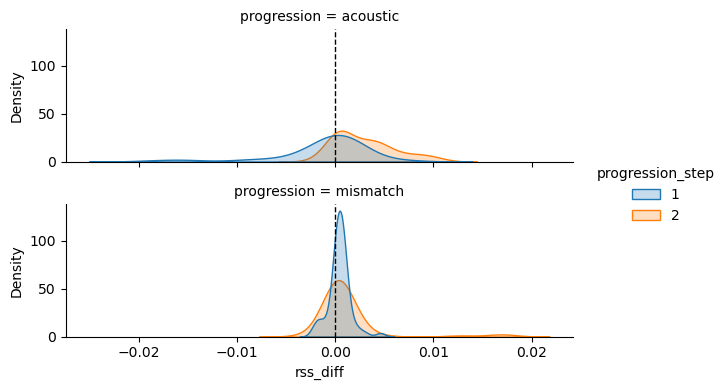

In [8]:
g = sns.displot(data=all_results_df.assign(progression_step=all_results_df.progression_step.astype(str)),
                x="rss_diff",
                hue="progression_step", row="progression",
                height=2, aspect=3, kind="kde", fill=True)
for ax in g.axes.flat:
    ax.axvline(0, color="black", linestyle="--", linewidth=1)

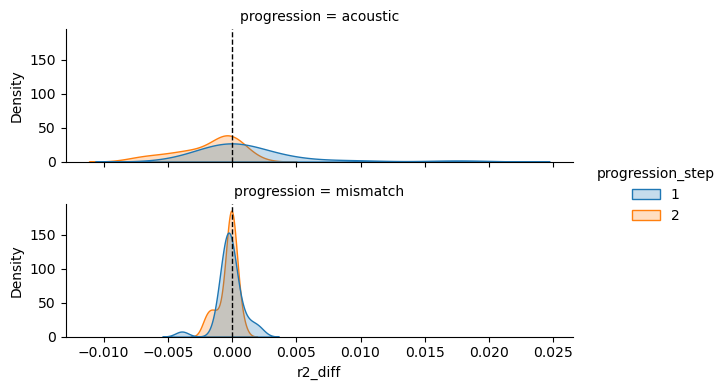

In [9]:
g = sns.displot(data=all_results_df.assign(progression_step=all_results_df.progression_step.astype(str)),
                x="r2_diff",
                hue="progression_step", row="progression",
                height=2, aspect=3, kind="kde", fill=True)
for ax in g.axes.flat:
    ax.axvline(0, color="black", linestyle="--", linewidth=1)

In [10]:
all_results_df.loc[all_results_df.ftest_pval < 0.05].sort_values("ftest_pval")

,subject,progression,progression_step,electrode,r2_pre,r2_post,rss_pre,rss_post,df_diff,df_residual,ftest_stat,ftest_pval,rss_diff,long_name,type,roi,speech_responsive,r2_diff
27,EC250,acoustic,1,215,0.046851,0.064466,1.003270,0.984729,243,102708,7.958092,9.940204e-258,-0.018541,Inferior88,grid,superiortemporal,True,0.017615
77,EC253,acoustic,1,21,0.031876,0.041310,1.529987,1.515077,243,102708,4.159245,1.536533e-93,-0.014909,AnteriorGrid22,grid,postcentral,True,0.009434
104,EC287,acoustic,1,124,-0.022502,-0.013947,1.035748,1.027083,243,68148,2.366036,9.076254e-29,-0.008665,TemporalGrid125,grid,superiortemporal,False,NaN
28,EC250,acoustic,1,216,0.015503,0.020762,1.205816,1.199374,243,102708,2.270015,6.230679e-26,-0.006441,Inferior89,grid,superiortemporal,True,0.005259
43,EC282,acoustic,1,84,-0.002842,0.007772,1.500747,1.484864,243,50868,2.239263,6.329682e-25,-0.015884,Temporal85,grid,superiortemporal,True,NaN
105,EC287,acoustic,1,182,-0.016575,-0.008615,1.151097,1.142085,243,68148,2.213157,3.265551e-24,-0.009013,Insula3,depth,Left-Cerebral-White-Matter,True,NaN
74,EC278,mismatch,2,90,-0.004624,-0.001574,1.048137,1.044954,243,137025,1.717241,2.522085e-11,-0.003182,Temporal91,grid,superiortemporal,True,NaN
3,EC243,acoustic,1,102,0.037579,0.041149,1.398385,1.393199,243,102708,1.573376,2.920643e-08,-0.005186,InferiorParietal103,grid,postcentral,True,0.003569
80,EC253,acoustic,1,179,-0.003292,-0.000189,1.198443,1.194736,243,102708,1.311466,8.021552e-04,-0.003707,PosteriorGrid52,grid,superiortemporal,True,NaN
79,EC253,acoustic,1,52,0.007401,0.010172,1.189558,1.186237,243,102708,1.183284,2.644946e-02,-0.003321,AnteriorGrid53,grid,superiortemporal,True,0.002771


In [11]:
all_results_df.loc[all_results_df.r2_diff > 0].sort_values("r2_diff", ascending=False)

,subject,progression,progression_step,electrode,r2_pre,r2_post,rss_pre,rss_post,df_diff,df_residual,ftest_stat,ftest_pval,rss_diff,long_name,type,roi,speech_responsive,r2_diff
27,EC250,acoustic,1,215,0.046851,0.064466,1.003270,0.984729,243,102708,7.958092,9.940204e-258,-0.018541,Inferior88,grid,superiortemporal,True,0.017615
77,EC253,acoustic,1,21,0.031876,0.041310,1.529987,1.515077,243,102708,4.159245,1.536533e-93,-0.014909,AnteriorGrid22,grid,postcentral,True,0.009434
28,EC250,acoustic,1,216,0.015503,0.020762,1.205816,1.199374,243,102708,2.270015,6.230679e-26,-0.006441,Inferior89,grid,superiortemporal,True,0.005259
3,EC243,acoustic,1,102,0.037579,0.041149,1.398385,1.393199,243,102708,1.573376,2.920643e-08,-0.005186,InferiorParietal103,grid,postcentral,True,0.003569
79,EC253,acoustic,1,52,0.007401,0.010172,1.189558,1.186237,243,102708,1.183284,2.644946e-02,-0.003321,AnteriorGrid53,grid,superiortemporal,True,0.002771
1,EC243,acoustic,1,87,0.000327,0.002541,1.390907,1.387826,243,102708,0.938177,7.469543e-01,-0.003081,InferiorParietal88,grid,postcentral,True,0.002214
168,EC260,mismatch,1,76,0.003307,0.005426,1.028164,1.025979,243,102708,0.900451,8.652749e-01,-0.002186,FrontalGrid77,grid,precentral,True,0.002119
70,EC278,mismatch,1,27,0.010701,0.012488,1.039585,1.037707,243,137268,1.022347,3.918859e-01,-0.001878,Temporal28,grid,middletemporal,True,0.001787
72,EC278,mismatch,1,121,0.021100,0.022348,1.373588,1.371837,243,137268,0.721207,9.996417e-01,-0.001751,Temporal122,grid,supramarginal,True,0.001248
7,EC243,acoustic,2,102,0.041149,0.042300,1.393199,1.391526,243,102465,0.507073,1.000000e+00,-0.001673,InferiorParietal103,grid,postcentral,True,0.001152


In [12]:
all_results_df.to_csv(outdir / "eois.csv", index=False)

In [13]:
acoustic_gradience_test = all_results_df.query("progression == 'acoustic' and progression_step == 2")
acoustic_gradience_test["improved"] = acoustic_gradience_test.r2_diff > 0
acoustic_gradience_test.groupby("improved").roi.value_counts()

/tmp/ipykernel_3883021/84129328.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acoustic_gradience_test["improved"] = acoustic_gradience_test.r2_diff > 0


improved  roi                         
False     superiortemporal                29
          postcentral                      6
          supramarginal                    4
          Left-Cerebral-White-Matter       2
          Left-Hippocampus                 2
          ctx_rh_S_circular_insula_inf     2
          ctx_rh_G_temp_sup-Plan_tempo     1
          fusiform                         1
          middletemporal                   1
True      superiortemporal                 3
          Unknown                          1
          postcentral                      1
Name: count, dtype: int64

In [21]:
sns.set(context="paper", font_scale=2)

Text(0, 0.5, '')

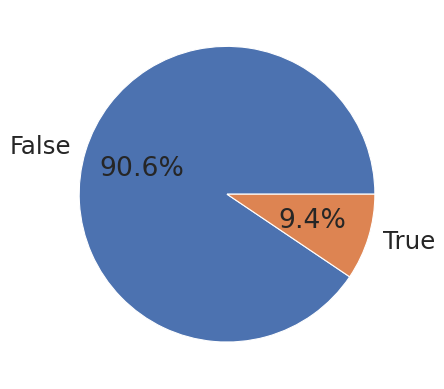

In [22]:
# plot pie chart with percent annotation
ax = acoustic_gradience_test.improved.value_counts().plot.pie(autopct='%1.1f%%')
ax.set_ylabel(None)